This code calculates the SHAP values, plots some SHAP plots and analyses subgroups

Import libraries

In [9]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

Some configurations

In [10]:
BINARY_PFS = True   # os_label is binary (Short resp / Long resp) for the TCGA cohort

Load best model and its train & test split

In [11]:
pipeline = joblib.load(f'../saved-models/tcga-model.joblib')
x_train = pd.read_csv(f"../dataset/created/x_train_tcga.csv")
x_test = pd.read_csv(f"../dataset/created/x_test_tcga.csv")
y_train = pd.read_csv(f"../dataset/created/y_train_tcga.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/y_test_tcga.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])

Evaluate the model

              precision    recall  f1-score   support

  Short resp       0.87      0.77      0.82       172
   Long resp       0.72      0.83      0.77       120

    accuracy                           0.80       292
   macro avg       0.79      0.80      0.80       292
weighted avg       0.81      0.80      0.80       292



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


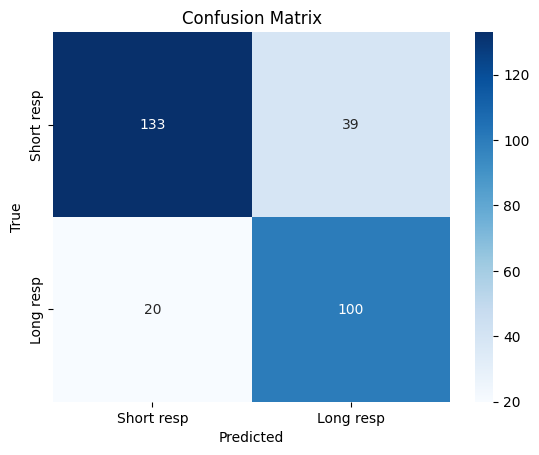

In [12]:
target_names = ['Short resp', 'Long resp']

y_pred = pipeline.predict(x)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Calculate SHAP values

In [13]:
model = pipeline[-1]

x_train_scaled = pipeline[:-1].transform(x_train)   # x -> preprocessed -> scaler
x_scaled = pipeline[:-1].transform(x)

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('categorical__', '')
     .replace('ordinal__', '')
     .replace('numeric__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

explainer = shap.LinearExplainer(model, x_train_scaled)   # pass only Train as background
shap_values = explainer(x_scaled)                         # explain both Train+Test
shap_values.feature_names = feature_names

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Plot all samples using PCA, UMAP, ...

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


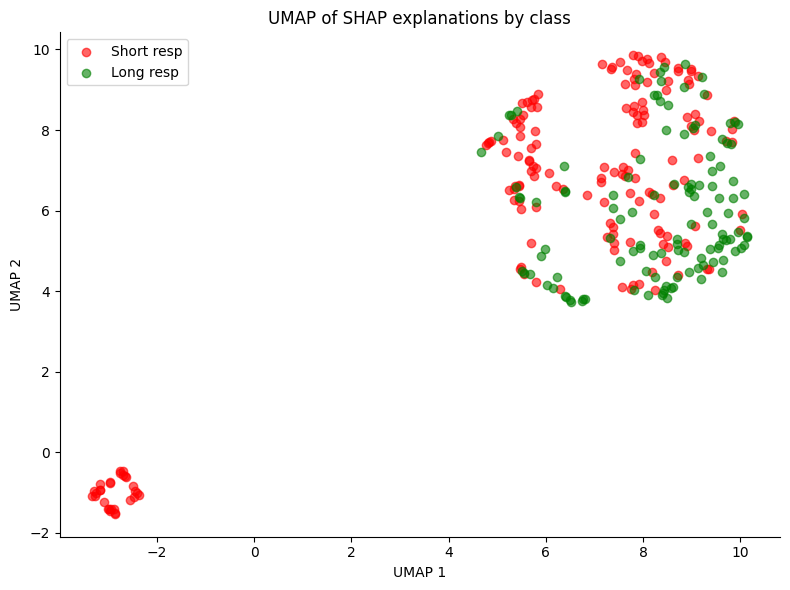

In [14]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# # PCA — pass explained variance
# pca = PCA(n_components=2)
# sv_2d = pca.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


Global interpretability

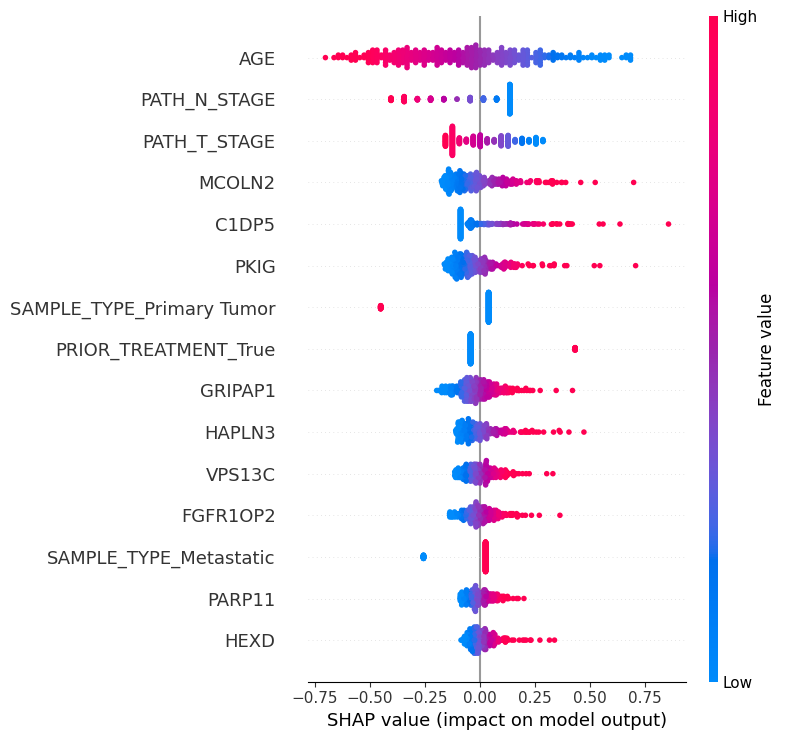

In [15]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=15)

Count FP, FN .. and their log-odds

In [16]:
y_pred = model.predict(x_scaled)
misclassified = np.where(y_pred != y)[0]
print(f"Misclassified indices: {misclassified}\n")

fp = np.where((y == 0) & (y_pred == 1))[0]  # misclassified short
fn = np.where((y == 1) & (y_pred == 0))[0]  # misclassified long
tn = np.where((y == 0) & (y_pred == 0))[0]   # correctly predicted short
tp = np.where((y == 1) & (y_pred == 1))[0]   # correctly predicted long
print(f'FP (misclassified short): {fp}')
print(f'FN (misclassified long): {fn}')
print(f'TN (correct short): {tn}')
print(f'TP (correct long): {tp}')

Misclassified indices: [  2   5   8  11  12  20  21  31  38  39  43  53  54  80  83  87  91  99
 102 105 110 116 117 118 130 134 136 141 145 151 160 165 173 184 187 189
 190 199 205 217 218 220 222 225 236 239 241 253 260 262 267 269 272 273
 277 282 283 284 290]

FP (misclassified short): [  5  11  12  54  80  91 102 105 116 117 118 130 134 136 141 145 151 160
 165 173 184 187 190 199 205 217 218 222 225 236 239 262 267 269 272 273
 277 283 284]
FN (misclassified long): [  2   8  20  21  31  38  39  43  53  83  87  99 110 189 220 241 253 260
 282 290]
TN (correct short): [  0   1   9  16  17  19  22  25  26  27  35  37  42  47  48  49  50  52
  58  60  61  62  63  64  65  67  68  69  70  71  72  73  74  75  76  77
  78  79  81  82  84  85  86  90  93  94  95  96  97  98 100 103 113 119
 120 123 129 135 139 140 146 147 150 152 153 155 156 158 161 162 164 166
 167 168 169 171 172 175 178 180 181 186 188 191 192 193 194 195 196 198
 201 202 204 206 207 209 211 212 213 214 215 216 221 224

In [17]:
log_odds = model.decision_function(x_scaled)

print(f'FP log-odds: {log_odds[fp]}')
print(f'FN log-odds: {log_odds[fn]}')
print(f'TN log-odds: {log_odds[tn]}')
print(f'TP log-odds: {log_odds[tp]}')

FP log-odds: [0.03918542 0.63130966 0.25827623 0.78278501 0.20131222 0.01484107
 0.05655393 0.0791817  0.17771517 0.49994679 1.02778835 0.08761016
 0.397492   0.38624408 0.00938705 0.32541439 0.10397983 0.07927916
 0.28084057 0.14644463 0.46983666 1.01070688 0.2541411  0.34822095
 0.17727052 0.03146147 0.59876146 0.6017378  0.14350811 0.51032119
 0.23687833 0.34983343 1.21573792 0.92208382 0.24529418 0.21998453
 0.75071473 0.64947264 0.45861906]
FN log-odds: [-0.18742072 -0.46965787 -0.26446884 -0.62060491 -0.82270589 -0.04195272
 -0.06371998 -0.46954256 -0.0074727  -0.44658852 -0.04993085 -0.42086925
 -0.46340177 -0.40436394 -0.48370284 -0.141771   -0.60324047 -0.37694335
 -0.36090023 -0.3396478 ]
TN log-odds: [-0.97658075 -1.42516053 -0.83678583 -1.05661412 -1.39371295 -0.76827425
 -0.02277549 -0.30214426 -0.6032105  -0.49092742 -0.576937   -0.99434791
 -0.87219129 -1.16155409 -1.14588605 -0.77337921 -0.61435545 -0.75887291
 -0.93851877 -0.06842213 -0.39028847 -0.18967294 -1.23164896

Subgroups analysis

In [19]:
# Some helper functions
def plot_umap_clusters(cluster_labels, n_clusters, title):
    
    cluster_colors = plt.cm.tab10.colors[:n_clusters]
    markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

    fig, ax = plt.subplots(figsize=(8, 6))

    for k in range(n_clusters):
        for cls in np.unique(y_arr):
            mask = (cluster_labels == k) & (y_arr == cls)
            label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
            ax.scatter(
                sv_2d[mask, 0], sv_2d[mask, 1],
                c=[cluster_colors[k]], marker=markers[cls],
                alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
            )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    
def count_samples_each_cluster(cluster_labels, n_clusters):
    for k in range(n_clusters):
        mask = cluster_labels == k
        counts = pd.Series(y_arr[mask]).value_counts().sort_index()
        short = counts.get(0, 0)
        long  = counts.get(1, 0)
        print(f"Cluster {k}: {short} Short resp, {long} Long resp")
        
def plot_heatmap_clusters(sv_df, cluster_labels, top_k, title, subset_clusters=None):
    
    sv_df["cluster"] = cluster_labels
    cluster_means = sv_df.groupby("cluster").mean()
    fig_height = 4
    
    if subset_clusters is not None:
        cluster_means = cluster_means.loc[subset_clusters]
        fig_height = 3

    # keep top 20 features with highest variance across clusters
    top_features = cluster_means.std(axis=0).nlargest(top_k).index
    heatmap_data = cluster_means[top_features]

    fig, ax = plt.subplots(figsize=(14, fig_height))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm", center=0,
        annot=True, fmt=".2f",
        linewidths=0.4, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Cluster")
    plt.xticks()
    plt.tight_layout()
    plt.show()


Subgroups analysis with KMeans

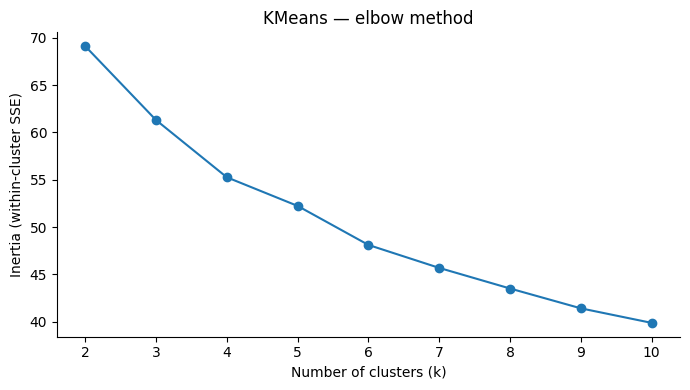

In [20]:
from sklearn.cluster import KMeans

# KMeans elbow
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sv_input)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("KMeans — elbow method")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

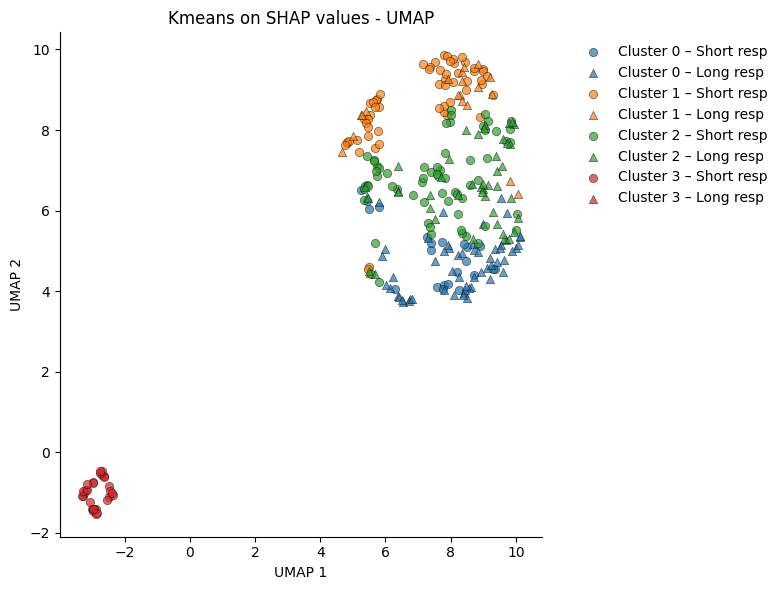

Cluster 0: 22 Short resp, 57 Long resp
Cluster 1: 58 Short resp, 20 Long resp
Cluster 2: 63 Short resp, 43 Long resp
Cluster 3: 29 Short resp, 0 Long resp


In [21]:
from sklearn.cluster import KMeans

n_clusters = 4

# cluster in full SHAP space
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_kmeans = kmeans.fit_predict(sv_input)

# use sv_2d only for visualization
plot_umap_clusters(cluster_labels_kmeans, n_clusters, 'Kmeans on SHAP values - UMAP')

count_samples_each_cluster(cluster_labels_kmeans, n_clusters)


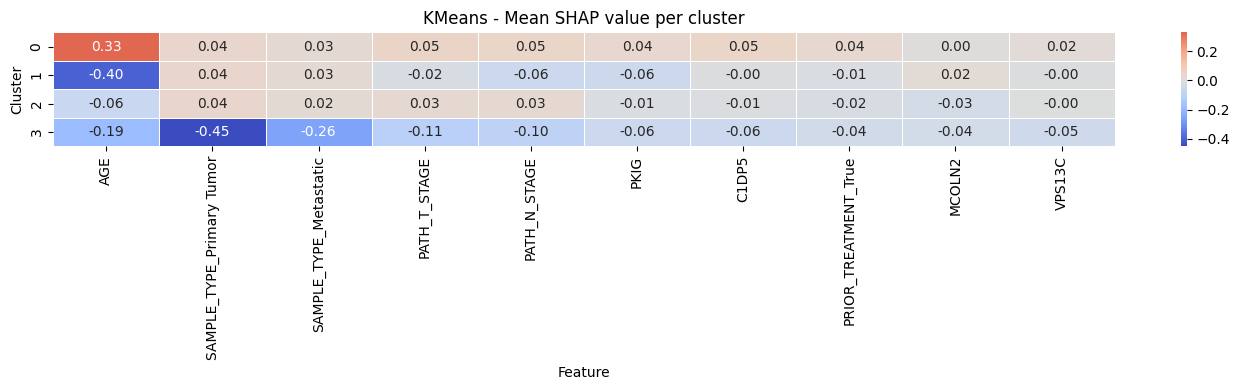

In [22]:
sv_df = pd.DataFrame(shap_values.values, columns=feature_names)

plot_heatmap_clusters(sv_df, cluster_labels_kmeans, top_k=10, title='KMeans - Mean SHAP value per cluster')

Subgroups analysis with Hierarchical clustering

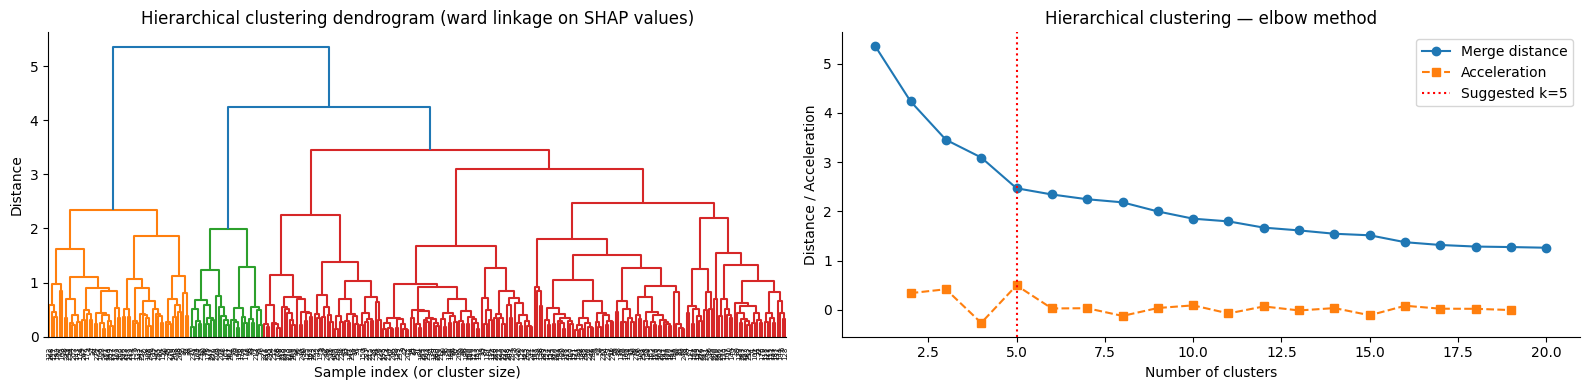

Suggested number of clusters (hierarchical): 5


In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(sv_input, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Dendrogram
dendrogram(Z, ax=axes[0])
axes[0].set_title("Hierarchical clustering dendrogram (ward linkage on SHAP values)")
axes[0].set_xlabel("Sample index (or cluster size)")
axes[0].set_ylabel("Distance")
axes[0].spines[["top", "right"]].set_visible(False)

# Elbow: last merge distances and their acceleration
last = Z[-20:, 2][::-1]          # top 20 merge distances, largest first
acceleration = np.diff(last, 2)   # second derivative — peak = elbow
suggested_k = int(acceleration.argmax()) + 2
idxs = np.arange(1, len(last) + 1)

axes[1].plot(idxs, last, marker="o", label="Merge distance")
axes[1].plot(idxs[1:-1], acceleration, marker="s", linestyle="--", label="Acceleration")
axes[1].axvline(x=suggested_k, color="red", linestyle=":", label=f"Suggested k={suggested_k}")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Distance / Acceleration")
axes[1].set_title("Hierarchical clustering — elbow method")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Suggested number of clusters (hierarchical): {suggested_k}")

Number of clusters at threshold 3.8: 3


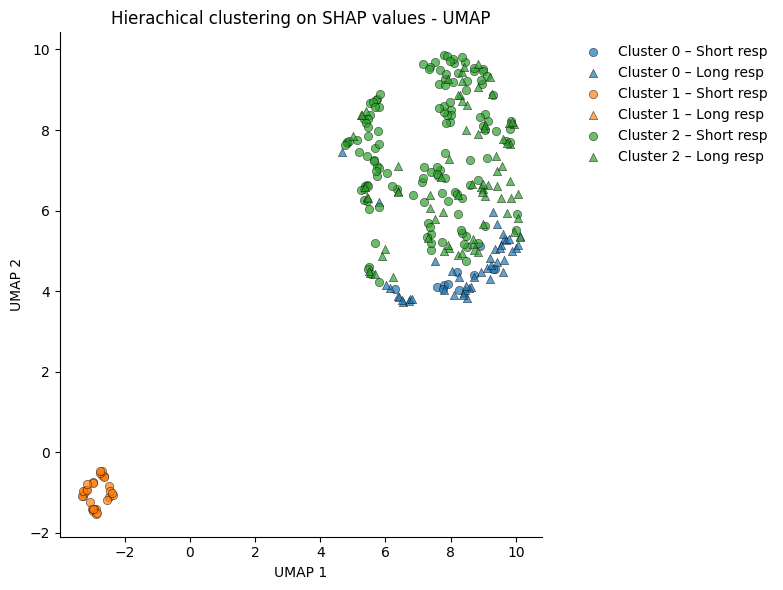

Cluster 0: 11 Short resp, 45 Long resp
Cluster 1: 29 Short resp, 0 Long resp
Cluster 2: 132 Short resp, 75 Long resp


In [24]:
dist_threshold = 3.8   # adjust based on dendrogram
cluster_labels_hier = fcluster(Z, t=dist_threshold, criterion="distance") - 1  # 0-indexed
n_clusters_hier = cluster_labels_hier.max() + 1
print(f"Number of clusters at threshold {dist_threshold}: {n_clusters_hier}")

# use sv_2d only for visualization
plot_umap_clusters(cluster_labels_hier, n_clusters_hier, 'Hierachical clustering on SHAP values - UMAP')

count_samples_each_cluster(cluster_labels_hier, n_clusters_hier)

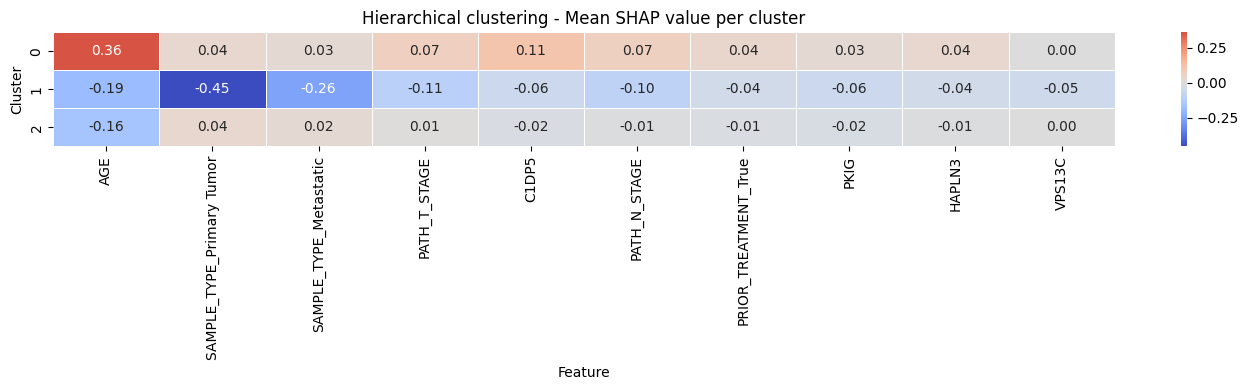

In [25]:
plot_heatmap_clusters(sv_df, cluster_labels_hier, top_k=10, title='Hierarchical clustering - Mean SHAP value per cluster')

Plot their corresponding raw values

In [28]:
subset_clusters = [0, 2]
explain_target = 1

maskA = (cluster_labels_hier == subset_clusters[0]) & (y_arr == explain_target)
maskB = (cluster_labels_hier == subset_clusters[1]) & (y_arr == explain_target)

pos_A = np.where(maskA)[0]
pos_B = np.where(maskB)[0]

cluster_means = sv_df.groupby("cluster").mean()
cluster_means = cluster_means.loc[subset_clusters]
top_features = cluster_means.std(axis=0).nlargest(10).index

x_display = pd.get_dummies(x).reset_index(drop=True)
valid_features = [f for f in top_features if f in x_display.columns]
print(x_display.iloc[pos_A][valid_features])
print(x_display.iloc[pos_B][valid_features])


      AGE   C1DP5    HAPLN3      PKIG   MCOLN2     STAT1     HEXD
4    42.0  0.7605   81.7268   76.6146   9.6890  748.9868  10.2304
18   30.0  0.0000    3.8991   43.2484  25.0767   47.6184   3.3128
23   39.0  0.4099   53.2610   99.3993  11.8437  283.8302  12.4461
28   42.0  1.3997   34.0271  162.6224   4.0973   74.7325  20.8045
29   39.0  0.0000  147.6856   43.2665   3.9985  386.2790  17.9300
30   19.0  0.7614   58.5259  173.4386  23.2657  384.2486  23.6846
32   18.0  0.4432   64.8542  126.2109  16.5952  228.7799   8.2613
33   23.0  0.9706   28.1135  124.0017   8.1311  122.2703  12.3615
34   36.0  0.7661   15.8269   89.2130   5.0124  125.3347  18.5958
40   27.0  0.3991   13.2295   89.6214   9.5173  215.2586  21.6644
44   52.0  1.6332   27.4704   53.2967   5.2501  112.1007  18.7187
45   25.0  0.0000   21.6125   67.7126   6.8189   80.8549  11.2308
57   45.0  1.6985   29.8029  259.6744   2.0062  419.7490  12.2537
92   20.0  0.2403   23.7684   53.5220   0.6150   53.8486   3.8105
106  43.0 